In [6]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [7]:
data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)

accuracy_score(y_test, lr.predict(X_test)), accuracy_score(y_test, dt.predict(X_test)), accuracy_score(y_test, rf.predict(X_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(0.9722222222222222, 0.9444444444444444, 1.0)

In [9]:
import matplotlib.pyplot as plt
import numpy as np

img = plt.imread('/content/image.jpg')
img = img / 255.0

In [10]:
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

In [11]:
from sklearn.decomposition import PCA

components = [5, 20, 50, 100]
reconstructed_images = []

for k in components:
    pca_r = PCA(n_components=k)
    pca_g = PCA(n_components=k)
    pca_b = PCA(n_components=k)

    R_k = pca_r.fit_transform(R)
    G_k = pca_g.fit_transform(G)
    B_k = pca_b.fit_transform(B)

    R_rec = pca_r.inverse_transform(R_k)
    G_rec = pca_g.inverse_transform(G_k)
    B_rec = pca_b.inverse_transform(B_k)

    img_rec = np.stack((R_rec, G_rec, B_rec), axis=2)
    reconstructed_images.append(img_rec)

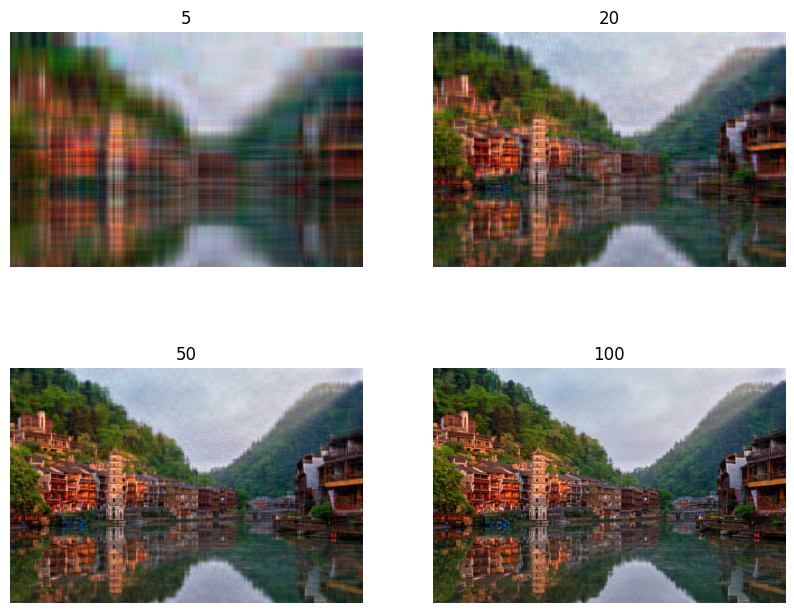

In [12]:
plt.figure(figsize=(10, 8))

for i, img_rec in enumerate(reconstructed_images):
    plt.subplot(2, 2, i+1)
    plt.imshow(img_rec)
    plt.title(f'{components[i]}')
    plt.axis('off')

plt.show()

In [13]:
def mse(original, compressed):
    return np.mean((original - compressed) ** 2)

original_size = img.size

for i, k in enumerate(components):
    compressed_size = k * (R.shape[0] + R.shape[1]) * 3
    ratio = original_size / compressed_size
    error = mse(img, reconstructed_images[i])
    print(k, round(ratio, 2), round(error, 5))

5 240.0 0.01172
20 60.0 0.00641
50 24.0 0.00366
100 12.0 0.0021


In [14]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [15]:
def weekly_model_comparison(X, y, use_pca=False):
    models = {
        "LR": LogisticRegression(max_iter=1000),
        "RF": RandomForestClassifier(),
        "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "SVM": SVC(),
        "KNN": KNeighborsClassifier()
    }

    results = []

    for name, model in models.items():
        steps = [("scaler", StandardScaler())]

        if use_pca:
            steps.append(("pca", PCA(n_components=0.95)))

        steps.append(("model", model))

        pipeline = Pipeline(steps)
        scores = cross_val_score(pipeline, X, y, cv=5)

        results.append({"Model": name, "Accuracy": scores.mean()})

    return pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

In [16]:
weekly_model_comparison(X, y, use_pca=True)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:30:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:30:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:30:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:30:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Model,Accuracy
3,SVM,0.983333
0,LR,0.983333
2,XGB,0.955079
4,KNN,0.949524
1,RF,0.949365
